In [1]:
""" Log
12/27/25 ---- Implemented AAA-greedy for Hubbard dimer of different sce/wce order.
Using the wce data up to t=1 and sce dat up to t=0.05 to construct the interpolation. 
01/01/26 -- Implemented the U 
"""

' Log\n12/27/25 ---- Implemented AAA-greedy for Hubbard dimer of different sce/wce order.\nUsing the wce data up to t=1 and sce dat up to t=0.05 to construct the interpolation. \n01/01/26 -- Implemented the U \n'

In [2]:
### Using AAA to interpolate G(t, U=1.0, iw_n).
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt
import sys, os
import analytic_solution as AS
import diff_G as diff
import utilities as ut
from adapol import anacont
from _bary_rational import AAA_adding0
import greedy_interpolation as greedy

In [3]:
beta = 20.0
Ntau = 401
Ns = 2
Nw = 4*int(beta)
Mat_fre = (2*np.linspace(0, Nw-1, Nw)+1)*np.pi/beta
wn = np.append(-np.flip(Mat_fre),Mat_fre)   # w_n = (2n+1)*pi/beta

In [21]:
Nt = 1001
T = 50
U_values_ED = np.linspace(0, T, Nt)
diff_order = 12
test_order = diff_order + 1
Gij_iwn_exact = np.zeros((len(U_values_ED), wn.size, Ns, Ns), dtype ='complex')
Gij_iwn_wce = np.zeros((test_order, len(U_values_ED), wn.size, Ns, Ns), dtype ='complex')
Gij_iwn_sce = np.zeros((test_order, len(U_values_ED), wn.size, Ns, Ns), dtype ='complex')
U = 1.0
for u in range(U_values_ED.size):
    Gij_iwn_exact[u] = AS.G_analytic(1.0, wn,  U_values_ED[u], beta)
    for order in range(test_order):
        Gij_iwn_wce[order, u] = diff.Gij_wce_series(order, 1.0,  U_values_ED[u] , wn)
        Gij_iwn_sce[order, u] = diff.Gij_sce_series(order, 1.0,  U_values_ED[u] , wn, beta)

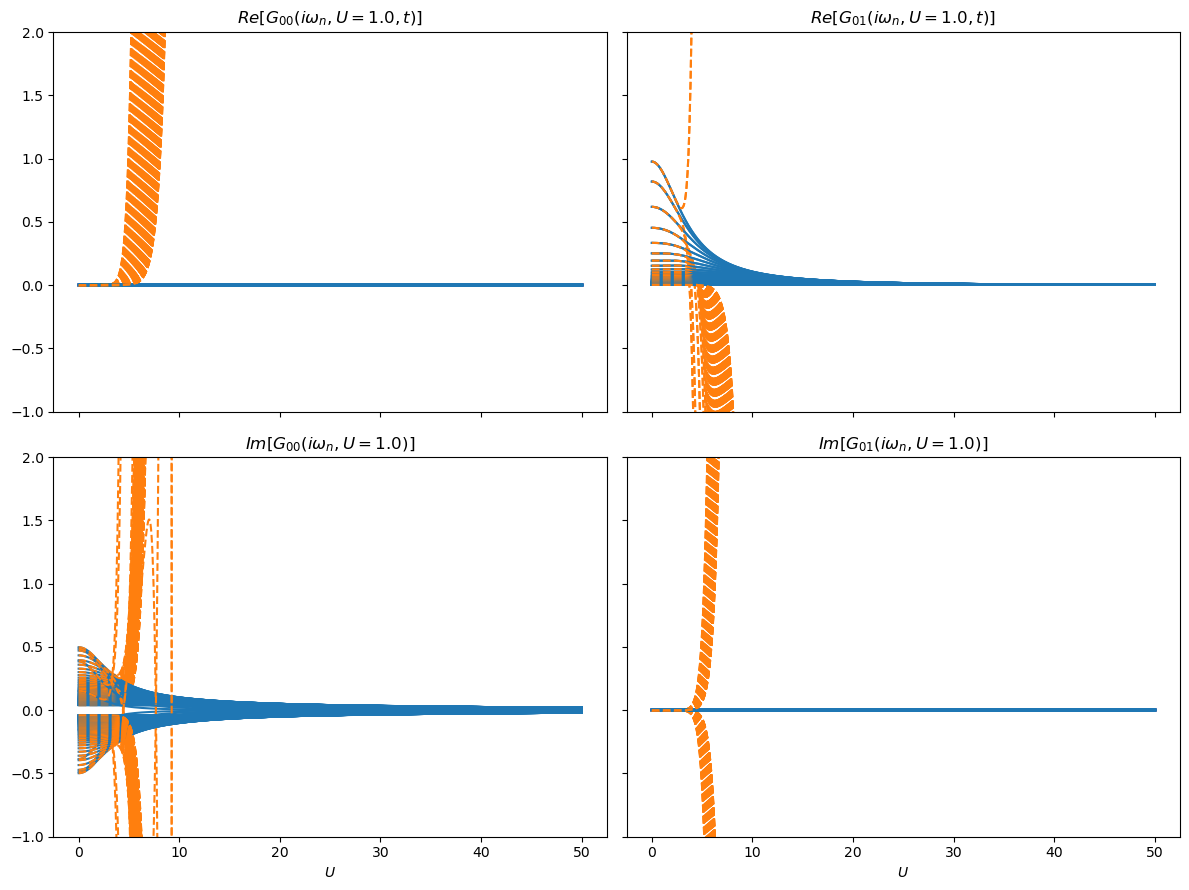

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
(ax11, ax12), (ax21, ax22) = axes

# (1,1) — like your figure(1)
for i in range(wn.size):
    ax11.plot(U_values_ED.real, Gij_iwn_exact[:, i, 0, 0 ].real, 'C0')
    ax11.plot(U_values_ED.real, Gij_iwn_wce[-1,:, i, 0, 0 ].real, 'C1--')
ax11.set_title(r'$Re[G_{00}(i\omega_n,U=%.1f, t)]$'%(U))
ax11.set_ylim([-1,2])
# (1,2) — like your figure(2)
for i in range(wn.size):
    ax12.plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0')
    ax12.plot(U_values_ED.real, Gij_iwn_wce[-1,:, i, 0,1 ].real, 'C1--')
ax12.set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%(U))

# (2,1) — like your figure(3)
for i in range(wn.size):
    ax21.plot(U_values_ED.real, Gij_iwn_exact[:, i, 0, 0 ].imag, 'C0')
    ax21.plot(U_values_ED.real, Gij_iwn_wce[-1,:, i, 0, 0 ].imag, 'C1--')
ax21.set_xlabel(r'$U$')
ax21.set_title(r'$Im[G_{00}(i\omega_n,U=%.1f)]$'%(U))

# (2,2) — like your figure(4)
for i in range(wn.size):
    ax22.plot(U_values_ED.real, Gij_iwn_exact[:, i, 0, 1 ].imag, 'C0')
    ax22.plot(U_values_ED.real, Gij_iwn_wce[-1, :, i, 0, 1 ].imag, 'C1--')
ax22.set_xlabel(r'$U$')
ax22.set_title(r'$Im[G_{01}(i\omega_n,U=%.1f)]$'%(U))

# Optional: remove duplicate y-labels on the right column
for ax in (ax12, ax22):
    ax.set_ylabel('')

fig.tight_layout()
plt.show()

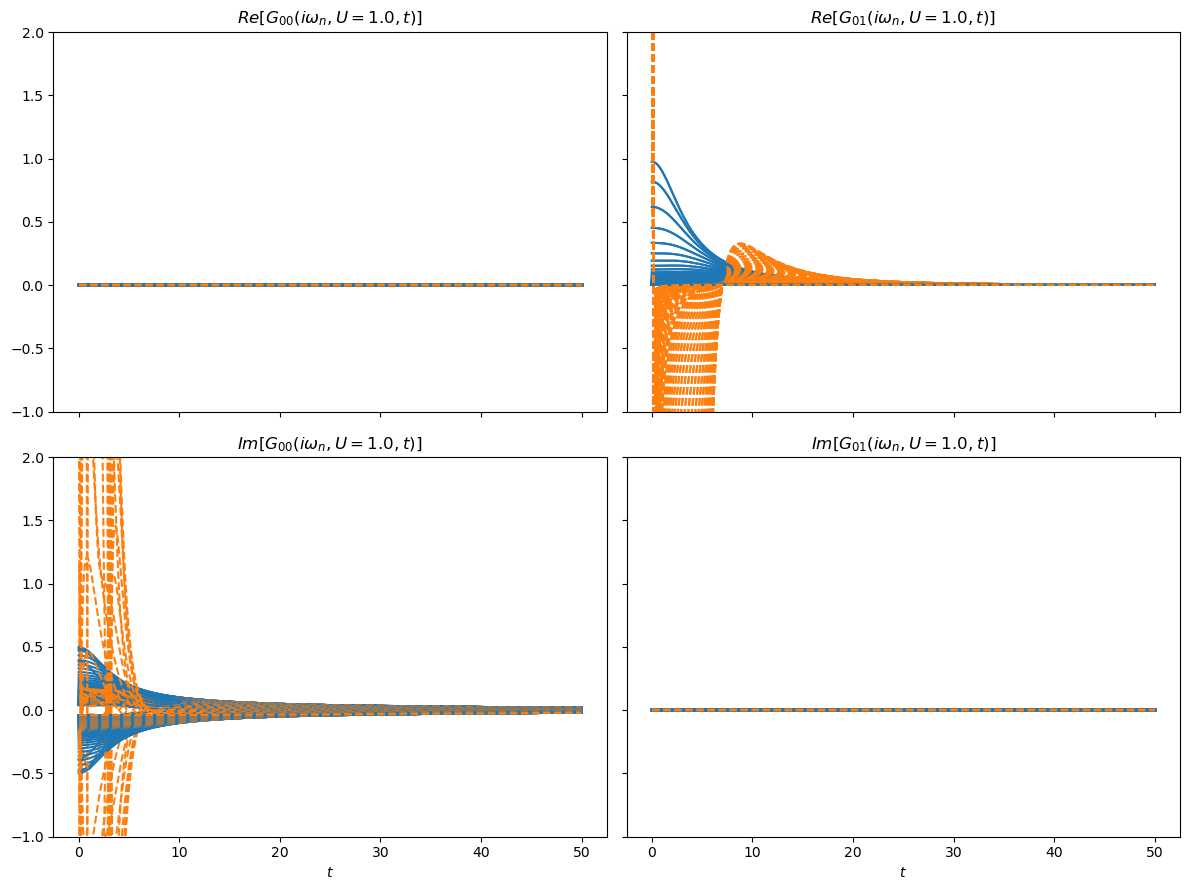

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
(ax11, ax12), (ax21, ax22) = axes

# (1,1) — like your figure(1)
for i in range(wn.size):
    ax11.plot(U_values_ED.real, Gij_iwn_exact[:, i, 0, 0 ].real, 'C0')
    ax11.plot(U_values_ED.real, Gij_iwn_sce[-1,:, i, 0, 0 ].real, 'C1--')
ax11.set_title(r'$Re[G_{00}(i\omega_n,U=%.1f, t)]$'%(U))
ax11.set_ylim([-1,2])
# (1,2) — like your figure(2)
for i in range(wn.size):
    ax12.plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0')
    ax12.plot(U_values_ED.real, Gij_iwn_sce[-1,:, i, 0,1 ].real, 'C1--')
ax12.set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%(U))

# (2,1) — like your figure(3)
for i in range(wn.size):
    ax21.plot(U_values_ED.real, Gij_iwn_exact[:, i, 0, 0 ].imag, 'C0')
    ax21.plot(U_values_ED.real, Gij_iwn_sce[-1,:, i, 0, 0 ].imag, 'C1--')
ax21.set_xlabel(r'$t$')
ax21.set_title(r'$Im[G_{00}(i\omega_n,U=%.1f, t)]$'%(U))

# (2,2) — like your figure(4)
for i in range(wn.size):
    ax22.plot(U_values_ED.real, Gij_iwn_exact[:, i, 0, 1 ].imag, 'C0')
    ax22.plot(U_values_ED.real, Gij_iwn_sce[-1, :, i, 0, 1 ].imag, 'C1--')
ax22.set_xlabel(r'$t$')
ax22.set_title(r'$Im[G_{01}(i\omega_n,U=%.1f, t)]$'%(U))

# Optional: remove duplicate y-labels on the right column
for ax in (ax12, ax22):
    ax.set_ylabel('')

fig.tight_layout()
plt.show()

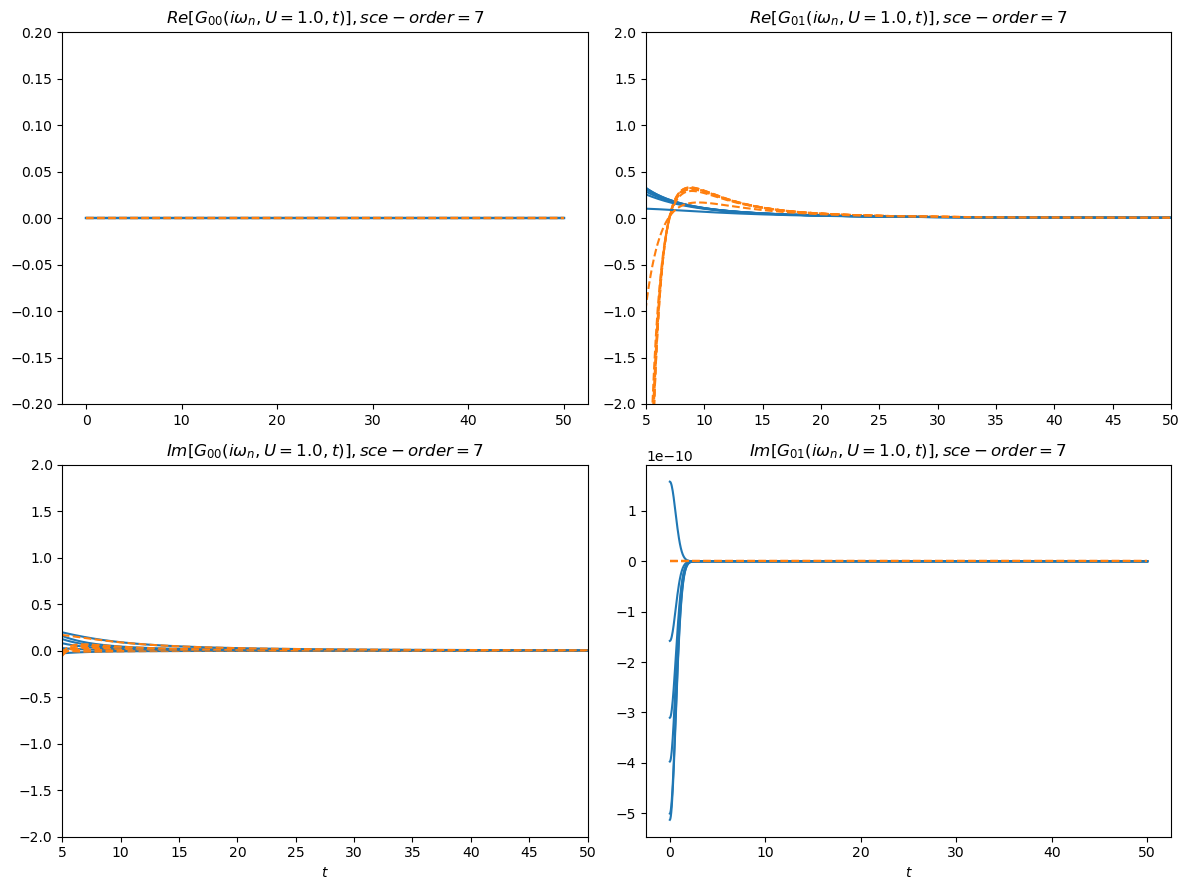

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False, sharey=False)
(ax11, ax12), (ax21, ax22) = axes
wn_id=[Nw, Nw-1, Nw-2, Nw-3, Nw-4, Nw-10]
sce_order = 7
# (1,1) — like your figure(1)
for i in wn_id:
    ax11.plot(U_values_ED.real, Gij_iwn_exact[:, i, 0, 0 ].real, 'C0')
    ax11.plot(U_values_ED.real, Gij_iwn_sce[sce_order,:, i, 0, 0 ].real, 'C1--')
ax11.set_title(r'$Re[G_{00}(i\omega_n,U=%.1f, t)], sce-order=%d$'%(U, sce_order))
ax11.set_ylim([-0.2,0.2])
# (1,2) — like your figure(2)
for i in wn_id:
    ax12.plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0')
    ax12.plot(U_values_ED.real, Gij_iwn_sce[sce_order,:, i, 0,1 ].real, 'C1--')
ax12.set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)], sce-order=%d$'%(U, sce_order))
ax12.set_ylim([-2,2])
ax12.set_xlim([5, T])
# (2,1) — like your figure(3)
for i in wn_id:
    ax21.plot(U_values_ED.real, Gij_iwn_exact[:, i, 0, 0 ].imag, 'C0')
    ax21.plot(U_values_ED.real, Gij_iwn_sce[sce_order,:, i, 0, 0 ].imag, 'C1--')
ax21.set_xlabel(r'$t$')
ax21.set_title(r'$Im[G_{00}(i\omega_n,U=%.1f, t)], sce-order=%d$'%(U, sce_order))
ax21.set_ylim([-2,2])
ax21.set_xlim([5, T])

# (2,2) — like your figure(4)
for i in wn_id:
    ax22.plot(U_values_ED.real, Gij_iwn_exact[:, i, 0, 1 ].imag, 'C0')
    ax22.plot(U_values_ED.real, Gij_iwn_sce[sce_order, :, i, 0, 1 ].imag, 'C1--')
ax22.set_xlabel(r'$t$')
ax22.set_title(r'$Im[G_{01}(i\omega_n,U=%.1f, t)], sce-order=%d$'%(U, sce_order))

# Optional: remove duplicate y-labels on the right column
for ax in (ax12, ax22):
    ax.set_ylabel('')

fig.tight_layout()
plt.show()

t_values that wce/sce works for G00: 2.3000000000000003 10.25
t_values that wce/sce works for G01: 2.35 37.4


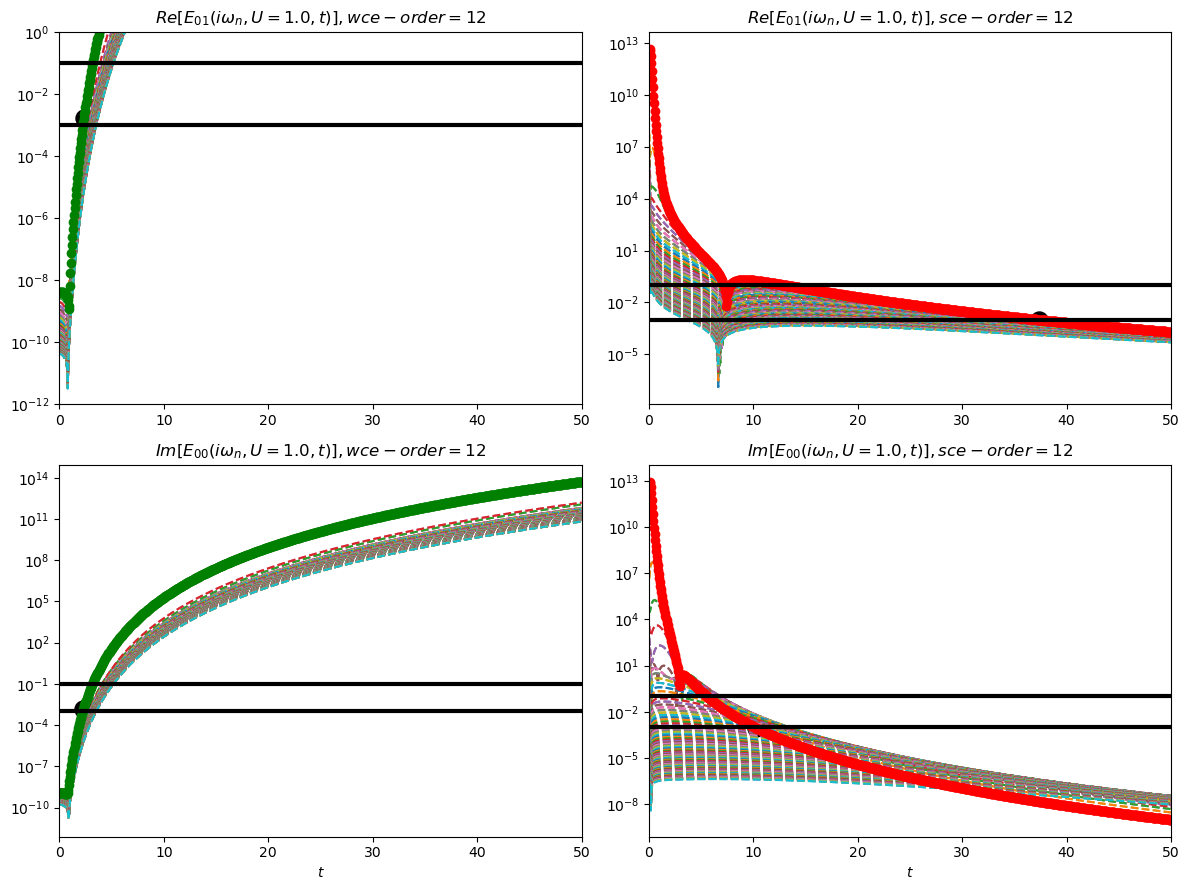

In [25]:
err_bar = 1e-3
err_bar2 = 1e-1
wn_id = Nw
interp_order = 12
wce00_err = np.abs(Gij_iwn_exact[:, wn_id, 0,0]-Gij_iwn_wce[interp_order, :, wn_id, 0,0]) 
wce01_err = np.abs(Gij_iwn_exact[:, wn_id, 0,1]-Gij_iwn_wce[interp_order, :, wn_id, 0,1])
sce00_err = np.abs(Gij_iwn_exact[:, wn_id, 0,0]-Gij_iwn_sce[interp_order, :, wn_id, 0,0]) 
sce01_err = np.abs(Gij_iwn_exact[:, wn_id, 0,1]-Gij_iwn_sce[interp_order, :, wn_id, 0,1])

idx = np.where(wce00_err > err_bar)[0]
wce00_err_idx = idx[0]+1
idx = np.where(wce01_err > err_bar)[0]
if len(idx)==0:
    wce01_err_idx = 0
else:
    wce01_err_idx = idx[0]+1
idx = np.where(sce00_err < err_bar)[0]
sce00_err_idx = idx[0]+1
idx = np.where(sce01_err < err_bar)[0]
sce01_err_idx = idx[0]+1
print("t_values that wce/sce works for G00:", U_values_ED[wce00_err_idx], U_values_ED[sce00_err_idx])
print("t_values that wce/sce works for G01:", U_values_ED[wce01_err_idx], U_values_ED[sce01_err_idx] )


    
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False, sharey=False)
(ax11, ax12), (ax21, ax22) = axes

# (1,2) — like your figure(2)
for i in range(wn.size):
    ax11.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, i, 0,1]-Gij_iwn_wce[interp_order, :, i, 0,1]), '--')
ax11.semilogy(U_values_ED.real, wce01_err, 'go', linewidth = 3)
ax11.semilogy(U_values_ED.real, err_bar+0*U_values_ED, 'k', linewidth = 3)
ax11.semilogy(U_values_ED.real, err_bar2+0*U_values_ED, 'k', linewidth = 3)
ax11.scatter(U_values_ED[wce01_err_idx].real, wce01_err[wce01_err_idx], color='k', s=150)
ax11.set_xlim([0, T])
ax11.set_ylim([1e-12, 1])
ax11.set_title(r'$Re[E_{01}(i\omega_n,U=%.1f, t)],wce-order= %d$'%(U, interp_order))

# (1,2) — like your figure(2)
for i in range(wn.size):
    ax12.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, i, 0,1]-Gij_iwn_sce[interp_order, :, i, 0,1]), '--')
ax12.semilogy(U_values_ED.real, sce01_err, 'ro', linewidth = 3)
ax12.semilogy(U_values_ED.real, err_bar+0*U_values_ED, 'k', linewidth = 3)
ax12.semilogy(U_values_ED.real, err_bar2+0*U_values_ED, 'k', linewidth = 3)
ax12.scatter(U_values_ED[sce01_err_idx].real, sce01_err[sce01_err_idx], color='k', s=150)
ax12.set_xlim([0, T])
ax12.set_title(r'$Re[E_{01}(i\omega_n,U=%.1f, t)],sce-order=%d$'%(U, interp_order))
# ax12.set_ylim(1e-10,1)

# (2,1) — like your figure(3)
for i in range(wn.size):
    ax21.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, i, 0,0]-Gij_iwn_wce[interp_order,:, i, 0,0]), '--')
ax21.semilogy(U_values_ED.real, wce00_err, 'go', linewidth = 3)
ax21.semilogy(U_values_ED.real, err_bar+0*U_values_ED, 'k', linewidth = 3)
ax21.semilogy(U_values_ED.real, err_bar2+0*U_values_ED, 'k', linewidth = 3)
ax21.scatter(U_values_ED[wce00_err_idx].real, wce00_err[wce00_err_idx], color='k', s=150)
ax21.set_xlim([0, T])
ax21.set_xlabel(r'$t$')
ax21.set_title(r'$Im[E_{00}(i\omega_n,U=%.1f, t)],wce-order=%d$'%(U, interp_order))

# (2,1) — like your figure(3)
for i in range(wn.size):
    ax22.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, i, 0,0]-Gij_iwn_sce[interp_order,:, i, 0,0]), '--')
ax22.semilogy(U_values_ED.real, sce00_err, 'ro', linewidth = 3)
ax22.semilogy(U_values_ED.real, err_bar+0*U_values_ED, 'k', linewidth = 3)
ax22.semilogy(U_values_ED.real, err_bar2+0*U_values_ED, 'k', linewidth = 3)
ax22.scatter(U_values_ED[sce00_err_idx].real, sce00_err[sce00_err_idx], color='k', s=150)
ax22.set_xlabel(r'$t$')
ax22.set_xlim([0, T])
ax22.set_title(r'$Im[E_{00}(i\omega_n,U=%.1f, t)],sce-order=%d$'%(U, interp_order))

# Optional: remove duplicate y-labels on the right column
for ax in (ax12, ax22):
    ax.set_ylabel('')

fig.tight_layout()
plt.show()




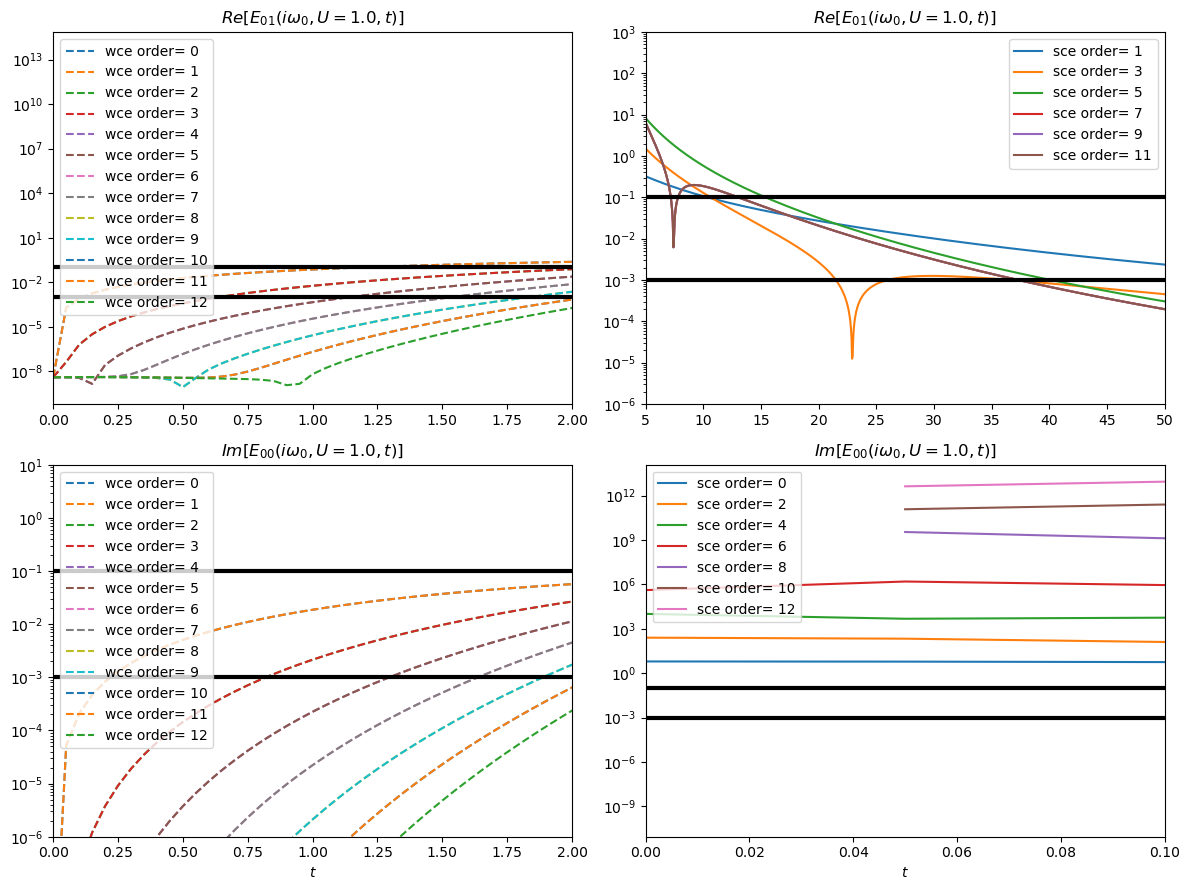

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False, sharey=False)
(ax11, ax12), (ax21, ax22) = axes

# (1,1) — like your figure(1)
# (1,2) — like your figure(2)
for i in range(test_order):
    ax11.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,1]-Gij_iwn_wce[i, :, Nw, 0,1]), '--', label = 'wce order= %d'%i)
ax11.semilogy(U_values_ED.real, err_bar+0*U_values_ED, 'k', linewidth = 3)
ax11.semilogy(U_values_ED.real, err_bar2+0*U_values_ED, 'k', linewidth = 3)
ax11.set_title(r'$Re[E_{01}(i\omega_0,U=%.1f, t)]$'%U)
ax11.set_xlim([0, 2])
ax11.legend()

# (1,2) — like your figure(2)
for i in range(test_order):
    if np.mod(i,2)==1:
        ax12.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,1]-Gij_iwn_sce[i, :, Nw, 0,1]), label = 'sce order= %d'%i)
ax12.semilogy(U_values_ED.real, err_bar+0*U_values_ED, 'k', linewidth = 3)
ax12.semilogy(U_values_ED.real, err_bar2+0*U_values_ED, 'k', linewidth = 3)
ax12.set_title(r'$Re[E_{01}(i\omega_0,U=%.1f, t)]$'%U)
ax12.set_xlim([5, T])
ax12.set_ylim([1e-6, 1000])
ax12.legend()

# (2,1) — like your figure(3)
for i in range(test_order):
    ax21.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,0]-Gij_iwn_wce[i,:, Nw, 0,0]), '--', label = 'wce order= %d'%i)
ax21.semilogy(U_values_ED.real, err_bar+0*U_values_ED, 'k', linewidth = 3)
ax21.semilogy(U_values_ED.real, err_bar2+0*U_values_ED, 'k', linewidth = 3)
ax21.set_xlabel(r'$t$')
ax21.set_title(r'$Im[E_{00}(i\omega_0,U=%.1f, t)]$'%U)
ax21.set_xlim([0,2])
ax21.legend()
ax21.set_ylim([1e-6, 10])
for i in range(test_order):
        if np.mod(i,2)==0:
            ax22.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,0]-Gij_iwn_sce[i,:, Nw, 0,0]), label = 'sce order= %d'%i)
ax22.semilogy(U_values_ED.real, err_bar+0*U_values_ED, 'k', linewidth = 3)
ax22.semilogy(U_values_ED.real, err_bar2+0*U_values_ED, 'k', linewidth = 3)
ax22.set_xlabel(r'$t$')
ax22.set_title(r'$Im[E_{00}(i\omega_0,U=%.1f, t)]$'%U)
ax22.set_xlim([0, 0.1])
ax22.legend()

# Optional: remove duplicate y-labels on the right column
for ax in (ax12, ax22):
    ax.set_ylabel('')
    

fig.tight_layout()
plt.show()

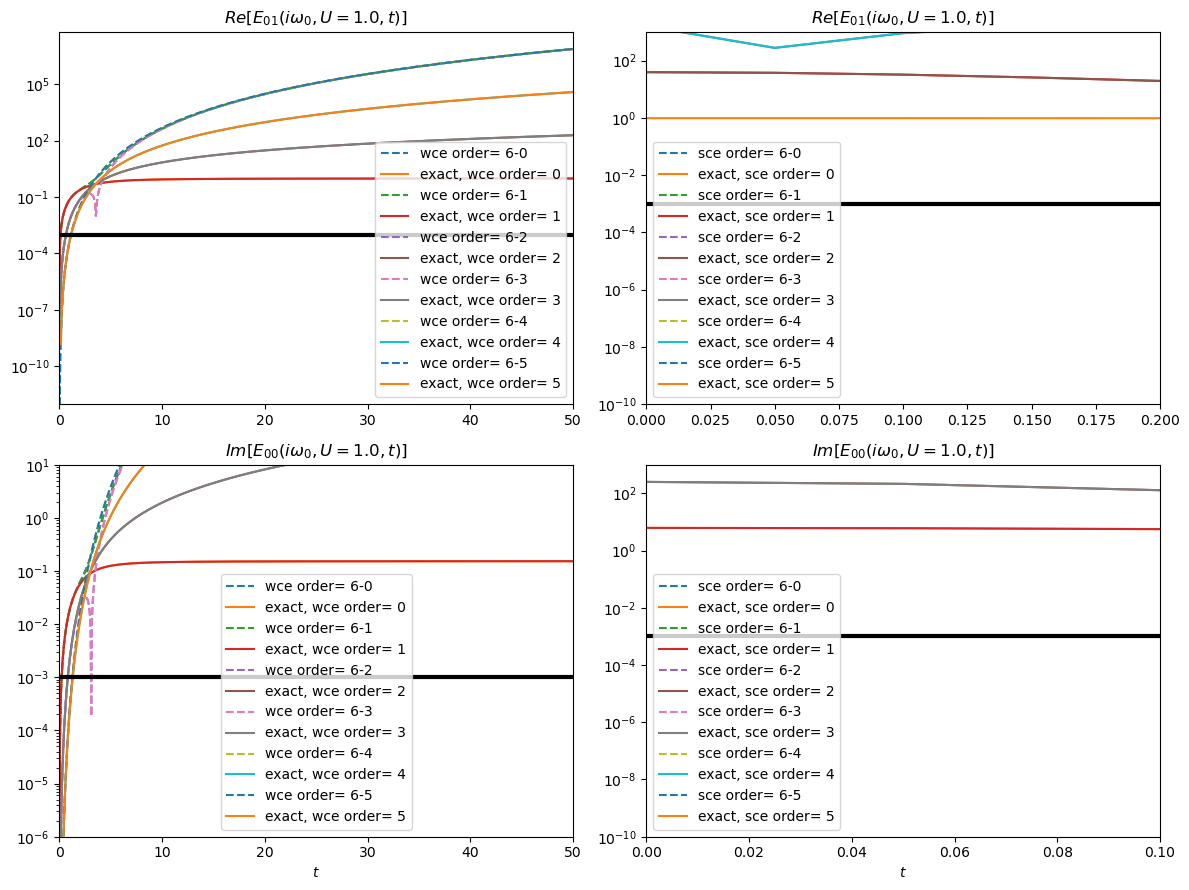

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False, sharey=False)
(ax11, ax12), (ax21, ax22) = axes

# (1,1) — like your figure(1)
# (1,2) — like your figure(2)
order_up = 6
for i in range(order_up):
    ax11.semilogy(U_values_ED.real, np.abs(Gij_iwn_wce[order_up, :, Nw, 0,1]-Gij_iwn_wce[i, :, Nw, 0,1]), '--', label = 'wce order= %d-%d'%(order_up,i))
    ax11.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,1]-Gij_iwn_wce[i, :, Nw, 0,1]), label = 'exact, wce order= %d'%i)
ax11.semilogy(U_values_ED.real, err_bar+0*U_values_ED, 'k', linewidth = 3)
ax11.set_title(r'$Re[E_{01}(i\omega_0,U=%.1f, t)]$'%U)
ax11.set_xlim([0, T])
ax11.legend()

# (1,2) — like your figure(2)
for i in range(order_up):
    ax12.semilogy(U_values_ED.real, np.abs(Gij_iwn_sce[order_up, :, Nw, 0,1]-Gij_iwn_sce[i, :, Nw, 0,1]), '--', label = 'sce order= %d-%d'%(order_up,i))
    ax12.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,1]-Gij_iwn_sce[i, :, Nw, 0,1]), label = 'exact, sce order= %d'%i)
ax12.semilogy(U_values_ED.real, err_bar+0*U_values_ED, 'k', linewidth = 3)
ax12.set_title(r'$Re[E_{01}(i\omega_0,U=%.1f, t)]$'%U)
ax12.set_xlim([0, 0.2])
ax12.set_ylim([1e-10, 1000])
ax12.legend()

# (2,1) — like your figure(3)
for i in range(order_up):
    ax21.semilogy(U_values_ED.real, np.abs(Gij_iwn_wce[order_up,:, Nw, 0,0]-Gij_iwn_wce[i,:, Nw, 0,0]), '--', label = 'wce order= %d-%d'%(order_up,i))
    ax21.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,0]-Gij_iwn_wce[i, :, Nw, 0,0]), label = 'exact, wce order= %d'%i)
ax21.semilogy(U_values_ED.real, err_bar+0*U_values_ED, 'k', linewidth = 3)
ax21.set_xlabel(r'$t$')
ax21.set_title(r'$Im[E_{00}(i\omega_0,U=%.1f, t)]$'%U)
ax21.set_xlim([0, T])
ax21.legend()
ax21.set_ylim([1e-6, 10])
for i in range(order_up):
    ax22.semilogy(U_values_ED.real, np.abs(Gij_iwn_sce[order_up,:, Nw, 0,0]-Gij_iwn_sce[i,:, Nw, 0,0]), '--',label = 'sce order= %d-%d'%(order_up,i))
    ax22.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,0]-Gij_iwn_sce[i, :, Nw, 0,0]), label = 'exact, sce order= %d'%i)
ax22.semilogy(U_values_ED.real, err_bar+0*U_values_ED, 'k', linewidth = 3)
ax22.set_xlabel(r'$t$')
ax22.set_title(r'$Im[E_{00}(i\omega_0,U=%.1f, t)]$'%U)
ax22.set_ylim([1e-10, 1000])
ax22.set_xlim([0, 0.1])
ax22.legend()

# Optional: remove duplicate y-labels on the right column
for ax in (ax12, ax22):
    ax.set_ylabel('')
    

fig.tight_layout()
plt.show()

In [37]:
### Constructing the interpolation data 
N_wce = 501
u_wce = 2.42
print("The wce U window is:", (0, u_wce))
U_wce = np.linspace(0, u_wce, N_wce)

G_wce = np.zeros((len(U_wce), wn.size, Ns, Ns), dtype ='complex')
for i in range(len(U_wce)):
    G_wce[i] = diff.Gij_wce_series(interp_order, 1.0,  U_wce[i] , wn)

N_sce = 51
u_sce = 20.4
print("The sce U window is:", (u_sce, T))
U_sce = np.linspace(u_sce, T, N_sce)

G_sce = np.zeros((len(U_sce), wn.size, Ns, Ns), dtype ='complex')
for i in range(len(U_sce)):
    G_sce[i] = diff.Gij_sce_series(interp_order, 1.0,  U_sce[i] , wn, beta)

U_app = np.concatenate([U_wce, U_sce], axis=0)
G_app = np.concatenate([G_wce, G_sce], axis=0)
print(U_app.shape)
print(G_app.shape)

The wce U window is: (0, 2.42)
The sce U window is: (20.4, 50)
(552,)
(552, 160, 2, 2)


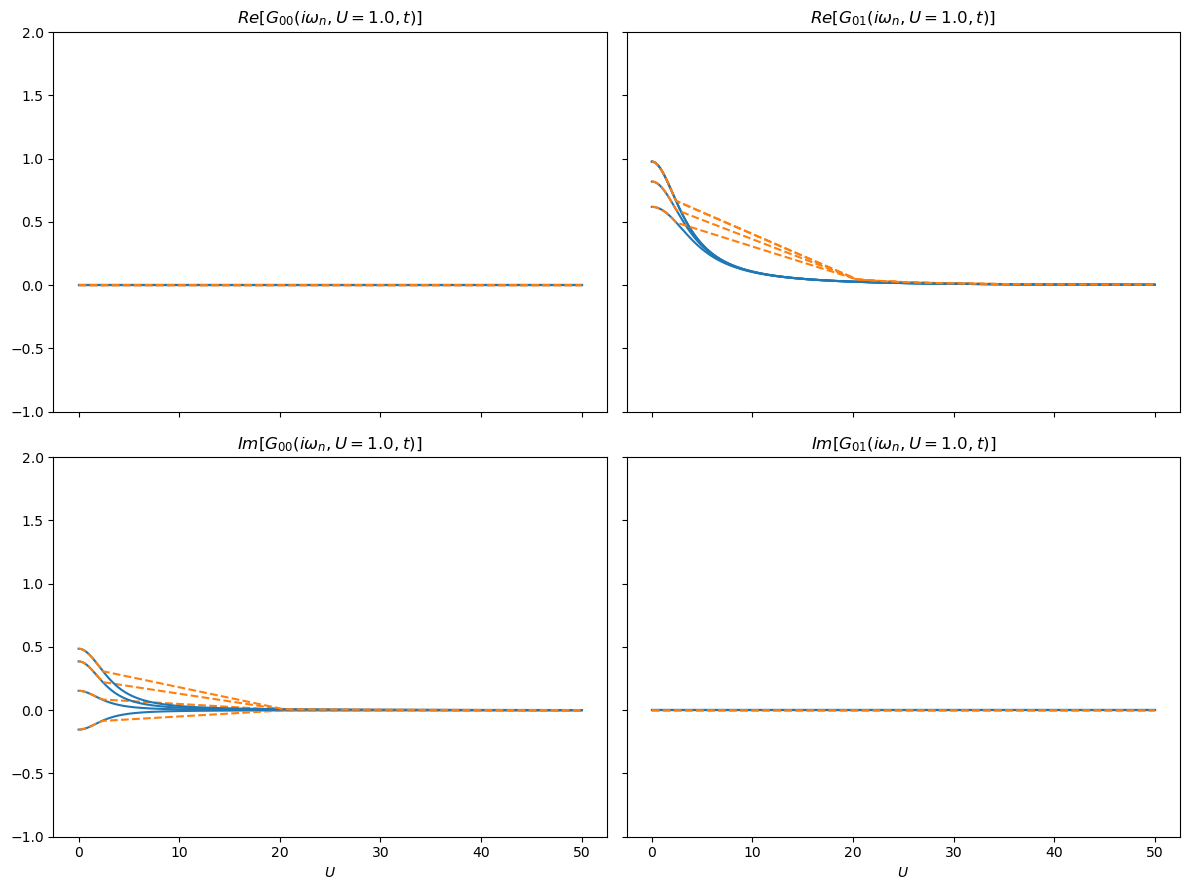

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
(ax11, ax12), (ax21, ax22) = axes

wn_id = [Nw, Nw-1, Nw-2, Nw-3]
# (1,1) — like your figure(1)
# for i in range(wn.size):
for i in wn_id:
    ax11.plot(U_values_ED.real, Gij_iwn_exact[:, i, 0, 0 ].real, 'C0')
    ax11.plot(U_app, G_app[:, i, 0, 0 ].real, 'C1--')
ax11.set_title(r'$Re[G_{00}(i\omega_n,U=%.1f, t)]$'%(U))
ax11.set_ylim([-1,2])
# (1,2) — like your figure(2)
# for i in range(wn.size):
for i in wn_id:
    ax12.plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0')
    ax12.plot(U_app, G_app[:, i, 0,1 ].real, 'C1--')
ax12.set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%(U))

# (2,1) — like your figure(3)
# for i in range(wn.size):
for i in wn_id:
    ax21.plot(U_values_ED.real, Gij_iwn_exact[:, i, 0, 0 ].imag, 'C0')
    ax21.plot(U_app, G_app[:, i, 0, 0 ].imag, 'C1--')
ax21.set_xlabel(r'$U$')
ax21.set_title(r'$Im[G_{00}(i\omega_n,U=%.1f, t)]$'%(U))

# (2,2) — like your figure(4)
# for i in range(wn.size):
for i in wn_id:
    ax22.plot(U_values_ED.real, Gij_iwn_exact[:, i, 0, 1 ].imag, 'C0')
    ax22.plot(U_app, G_app[:, i, 0, 1 ].imag, 'C1--')
ax22.set_xlabel(r'$U$')
ax22.set_title(r'$Im[G_{01}(i\omega_n,U=%.1f, t)]$'%(U))

# Optional: remove duplicate y-labels on the right column
for ax in (ax12, ax22):
    ax.set_ylabel('')

fig.tight_layout()
plt.show()

In [51]:
### AAA interpolation 
err_bar1 = 1e-5
G01_interp = np.zeros((U_values_ED.size, wn.size), dtype = complex)
G00_interp = np.zeros((U_values_ED.size, wn.size), dtype = complex)

for n in range(wn.size):
    print("n=", n)
    G00_interp_temp  = greedy.G_interp_v2(G_sce[:, n, 0, 0].imag, U_sce, G_wce[:, n, 0, 0].imag, U_wce, U_values_ED.real,  err=err_bar1, max_terms= 40)
    G00_interp[:, n] = 1j*G00_interp_temp
    G01_interp[:, n] = greedy.G_interp_v2(G_sce[:, n, 0, 1].real, U_sce, G_wce[:, n, 0, 1].real, U_wce, U_values_ED.real, err=err_bar1, max_terms= 40)
    # r00 = AAA_adding0(U_app, G_app[:, n, 0,0].imag, rtol=err_bar1, max_terms= 40)
    # G00_interp[:, n] = 1j*r00(U_values_ED.real)
    # r01 = AAA_adding0(U_app, G_app[:, n, 0,1].real, rtol=err_bar1, max_terms= 40)
    # G01_interp[:, n] = r01(U_values_ED.real)

n= 0
Best interpolation found
Best interpolation found
n= 1
Best interpolation found
Best interpolation found
n= 2
Best interpolation found
Best interpolation found
n= 3
Best interpolation found
Best interpolation found
n= 4
Best interpolation found
Best interpolation found
n= 5
Best interpolation found
Best interpolation found
n= 6
Best interpolation found
Best interpolation found
n= 7
Best interpolation found
Best interpolation found
n= 8
Best interpolation found
Best interpolation found
n= 9
Best interpolation found
Best interpolation found
n= 10
Best interpolation found
Best interpolation found
n= 11
Best interpolation found
Best interpolation found
n= 12
Best interpolation found
Best interpolation found
n= 13
Best interpolation found
Best interpolation found
n= 14
Best interpolation found
Best interpolation found
n= 15
Best interpolation found
Best interpolation found
n= 16
Best interpolation found
Best interpolation found
n= 17
Best interpolation found
Best interpolation found
n=

frequency = 0.15707963267948966
frequency = -0.15707963267948966
frequency = -0.47123889803846897
frequency = -0.7853981633974483
frequency = -1.0995574287564276


frequency = -1.413716694115407
frequency = -1.727875959474386
frequency = -2.0420352248333655
frequency = -2.356194490192345
frequency = -2.670353755551324
frequency = -2.9845130209103035
frequency = -4.5553093477052
frequency = -6.126105674500097
frequency = -7.696902001294992
frequency = -9.267698328089889




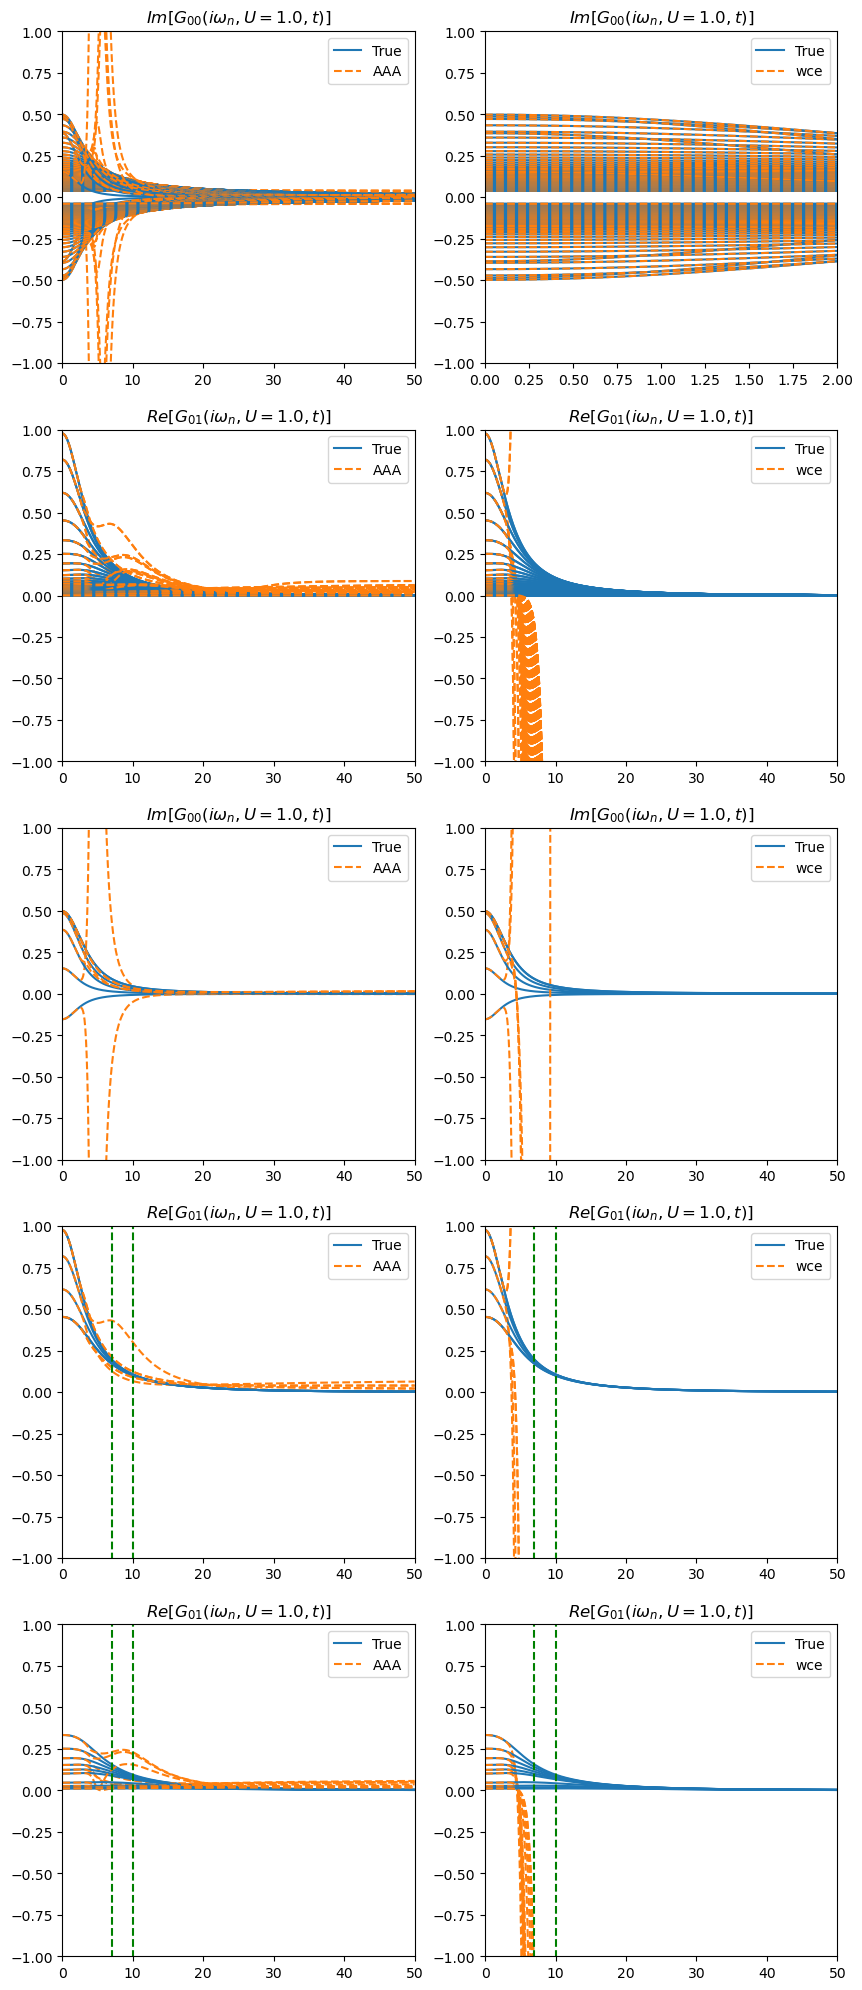

In [52]:
fig, ax = plt.subplots(5, 2, figsize=(10, 25), sharex=False, sharey=False)

for i in range(wn.size):
    ax[0,0].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,0].imag, 'C0')
    ax[0,0].plot(U_values_ED.real, G00_interp[:, i].imag, 'C1--')
ax[0,0].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,0].imag, 'C0', label = 'True')
ax[0,0].plot(U_values_ED.real, G00_interp[:, i].imag, 'C1--', label = 'AAA')
ax[0,0].set_ylim([-1,1])
ax[0,0].set_xlim([0, T])
ax[0,0].set_title(r'$Im[G_{00}(i\omega_n,U=%.1f, t)]$'%U)
ax[0,0].legend()

for i in range(wn.size):
    ax[1,0].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0')
    ax[1,0].plot(U_values_ED.real, G01_interp[:, i].real, 'C1--')
ax[1,0].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0', label = 'True')
ax[1,0].plot(U_values_ED.real, G01_interp[:, i].real, 'C1--', label = 'AAA')
ax[1,0].set_ylim([-1,1])
ax[1,0].set_xlim([0,T])
ax[1,0].set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%U)
ax[1,0].legend()

wn_id = [Nw, Nw-1, Nw-2, Nw-3, Nw-4]
for i in wn_id:
    print("frequency =", wn[i])
    ax[2,0].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,0 ].imag, 'C0')
    ax[2,0].plot(U_values_ED.real, G00_interp[:, i].imag, 'C1--')
ax[2,0].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,0 ].imag, 'C0', label = 'True')
ax[2,0].plot(U_values_ED.real, G00_interp[:, i].imag, 'C1--', label = 'AAA')
# ax[2,0].plot(U_wce+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'k--')
# ax[2,0].plot(U_sce+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'r--')
ax[2,0].set_ylim([-1,1])
ax[2,0].set_xlim([0, T])
ax[2,0].set_title(r'$Im[G_{00}(i\omega_n,U=%.1f, t)]$'%U)
ax[2,0].legend()

for i in wn_id:
    ax[3,0].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0')
    ax[3,0].plot(U_values_ED.real, G01_interp[:, i].real, 'C1--')
ax[3,0].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0', label = 'True')
ax[3,0].plot(U_values_ED.real, G01_interp[:, i].real, 'C1--', label = 'AAA')
ax[3,0].plot(7+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'g--')
ax[3,0].plot(10+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'g--')
# ax[3,0].plot(U_wce+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'k--')
# ax[3,0].plot(U_sce+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'r--')
ax[3,0].set_ylim([-1,1])
ax[3,0].set_xlim([0, T])
ax[3,0].set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%U)
ax[3,0].legend()

wn_id = [Nw-5, Nw-6, Nw-7, Nw-8, Nw-9, Nw-10, Nw-15, Nw-20, Nw-25, Nw-30]

print("\n")
for i in wn_id:
    print("frequency =", wn[i])
    ax[4,0].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0')
    ax[4,0].plot(U_values_ED.real, G01_interp[:, i].real, 'C1--')
ax[4,0].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0', label = 'True')
ax[4,0].plot(U_values_ED.real, G01_interp[:, i].real, 'C1--', label = 'AAA')
# ax[4,0].plot(u_wce+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'k--')
# ax[4,0].plot(u_sce+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'r--')
ax[4,0].plot(7+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'g--')
ax[4,0].plot(10+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'g--')
ax[4,0].set_ylim([-1,1])
ax[4,0].set_xlim([0,T])
ax[4,0].set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%U)
ax[4,0].legend()
#############################################################
for i in range(wn.size):
    ax[0,1].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,0].imag, 'C0')
    ax[0,1].plot(U_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,0].imag, 'C1--')
ax[0,1].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,0].imag, 'C0', label = 'True')
ax[0,1].plot(U_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,0].imag, 'C1--', label = 'wce')
ax[0,1].set_ylim([-1,1])
ax[0,1].set_xlim([0,2])
ax[0,1].set_title(r'$Im[G_{00}(i\omega_n,U=%.1f, t)]$'%U)
ax[0,1].legend()

for i in range(wn.size):
    ax[1,1].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0')
    ax[1,1].plot(U_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,1].real, 'C1--')
ax[1,1].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0', label = 'True')
ax[1,1].plot(U_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,1].real, 'C1--', label = 'wce')
ax[1,1].set_ylim([-1,1])
ax[1,1].set_xlim([0, T])
ax[1,1].set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%U)
ax[1,1].legend()

wn_id = [Nw, Nw-1, Nw-2, Nw-3, Nw-4]
for i in wn_id:
    ax[2,1].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,0 ].imag, 'C0')
    ax[2,1].plot(U_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,0].imag, 'C1--')
ax[2,1].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,0 ].imag, 'C0', label = 'True')
ax[2,1].plot(U_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,0].imag, 'C1--', label = 'wce')
# ax[2,1].plot(U_wce+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'k--')
# ax[2,1].plot(U_sce+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'r--')
ax[2,1].set_ylim([-1,1])
ax[2,1].set_xlim([0,T])
ax[2,1].set_title(r'$Im[G_{00}(i\omega_n,U=%.1f, t)]$'%U)
ax[2,1].legend()

for i in wn_id:
    ax[3,1].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0')
    ax[3,1].plot(U_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,1].real, 'C1--')
ax[3,1].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0', label = 'True')
ax[3,1].plot(U_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,1].real, 'C1--', label = 'wce')
ax[3,1].plot(7+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'g--')
ax[3,1].plot(10+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'g--')
# ax[3,1].plot(U_wce+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'k--')
# ax[3,1].plot(U_sce+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'r--')
ax[3,1].set_ylim([-1,1])
ax[3,1].set_xlim([0,T])
ax[3,1].set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%U)
ax[3,1].legend()

wn_id = [Nw-5, Nw-6, Nw-7, Nw-8, Nw-9, Nw-10, Nw-15, Nw-20, Nw-25, Nw-30]

print("\n")
for i in wn_id:
    ax[4,1].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0')
    ax[4,1].plot(U_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,1].real, 'C1--')
ax[4,1].plot(U_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0', label = 'True')
ax[4,1].plot(U_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,1].real, 'C1--', label = 'wce')
# ax[4,1].plot(U_wce+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'k--')
# ax[4,1].plot(U_sce+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'r--')
ax[4,1].plot(7+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'g--')
ax[4,1].plot(10+0*U_values_ED.real, np.linspace(-10,10,U_values_ED.size), 'g--')
ax[4,1].set_ylim([-1,1])
ax[4,1].set_xlim([0,T])
ax[4,1].set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%U)
ax[4,1].legend()

Text(0.5, 1.0, '$Re[E_{01}(i\\omega_n,U=1.0, t)]$')

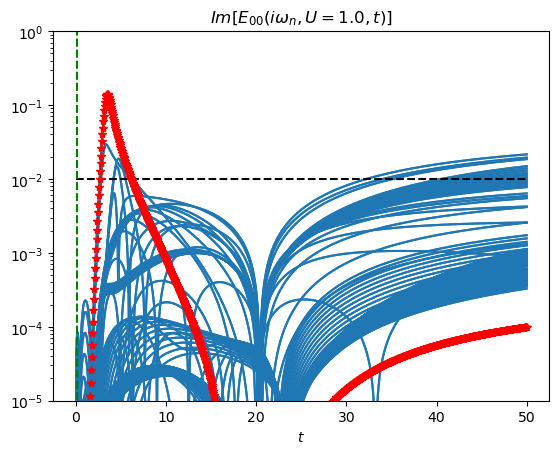

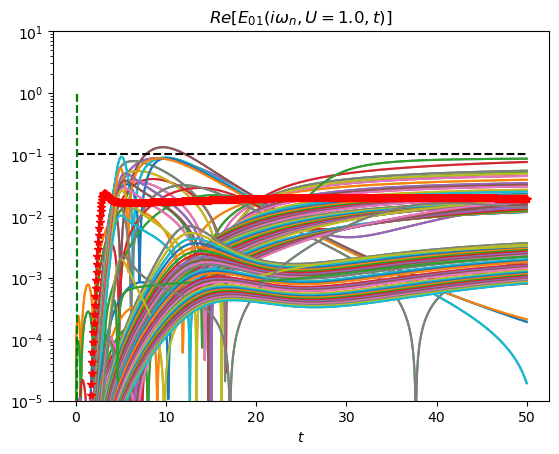

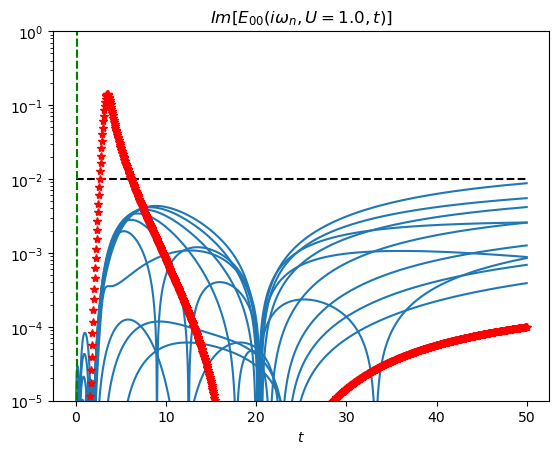

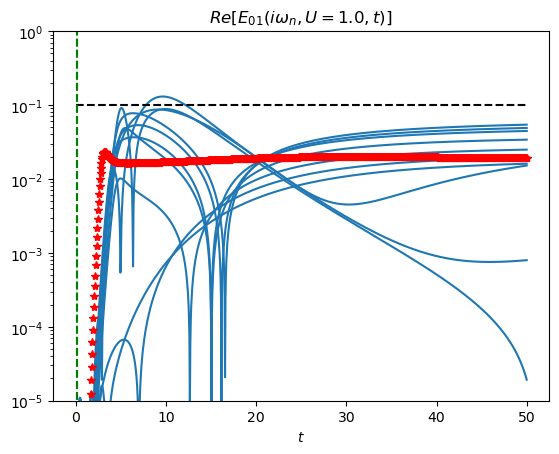

In [50]:
plt.figure(1)
for i in range(wn.size):
    plt.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, i, 0,0]-G00_interp[:, i]), 'C0', label = 'AAA')
plt.semilogy(U_values_ED.real, 1e-2+0*U_values_ED.real, 'k--')
plt.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,0]-G00_interp[:, Nw]), 'r*')
plt.semilogy(1/7+0*U_values_ED.real, np.linspace(0,1,U_values_ED.size), 'g--')
plt.semilogy(1/10+0*U_values_ED.real, np.linspace(0,1,U_values_ED.size), 'g--')
plt.ylim([1e-5,1])
plt.xlabel(r"$t$")
plt.title(r'$Im[E_{00}(i\omega_n,U=%.1f, t)]$'%U)

plt.figure(2)
for i in range(wn.size):
    plt.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, i, 0,1 ]-G01_interp[:, i]), label = 'AAA')
plt.semilogy(U_values_ED.real, 1e-1+0*U_values_ED.real, 'k--')
plt.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,1 ]-G01_interp[:, Nw]), 'r*', label = 'AAA')
plt.semilogy(1/7+0*U_values_ED.real, np.linspace(0,1,U_values_ED.size), 'g--')
plt.semilogy(1/10+0*U_values_ED.real, np.linspace(0,1,U_values_ED.size), 'g--')
plt.ylim([1e-5, 10])
plt.xlabel(r"$t$")
plt.title(r'$Re[E_{01}(i\omega_n,U=%.1f, t)]$'%U)

plt.figure(3)
for i in wn_id:
    plt.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, i, 0,0]-G00_interp[:, i]), 'C0', label = 'AAA')
plt.semilogy(U_values_ED.real, 1e-2+0*U_values_ED.real, 'k--')
plt.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,0]-G00_interp[:, Nw]), 'r*')
plt.semilogy(1/7+0*U_values_ED.real, np.linspace(0,1,U_values_ED.size), 'g--')
plt.semilogy(1/10+0*U_values_ED.real, np.linspace(0,1,U_values_ED.size), 'g--')
plt.ylim([1e-5,1])
plt.xlabel(r"$t$")
plt.title(r'$Im[E_{00}(i\omega_n,U=%.1f, t)]$'%U)

plt.figure(4)
for i in wn_id:
    plt.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, i, 0,1 ]-G01_interp[:, i]), 'C0', label = 'AAA')
plt.semilogy(U_values_ED.real, 1e-1+0*U_values_ED.real, 'k--')
plt.semilogy(U_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,1 ]-G01_interp[:, Nw]), 'r*', label = 'AAA')
plt.semilogy(1/7+0*U_values_ED.real, np.linspace(0,1,U_values_ED.size), 'g--')
plt.semilogy(1/10+0*U_values_ED.real, np.linspace(0,1,U_values_ED.size), 'g--')
plt.ylim([1e-5, 1])
plt.xlabel(r"$t$")
plt.title(r'$Re[E_{01}(i\omega_n,U=%.1f, t)]$'%U)

## print("This runs")
raise SystemExit

Ed_end = int(Nt/2)
Ed_gap = int(Nt/40)

tau = np.linspace(0,beta,Ntau)
Test_t = U_values_ED[0:Ed_end:Ed_gap]

print('The test ts are: ', Test_t)
G01_iwn_exact_CG = Gij_iwn_exact[0:Ed_end:Ed_gap,:,0,1]
G00_iwn_exact_CG = Gij_iwn_exact[0:Ed_end:Ed_gap,:,0,0]
G01_iwn_interp_CG = G01_interp[0:Ed_end:Ed_gap, :]
G00_iwn_interp_CG = G00_interp[0:Ed_end:Ed_gap, :]

    

Gij_iwn_exact_CG = np.zeros((len(Test_t), wn.size, Ns, Ns), dtype ='complex')
Gij_iwn_interp_CG = np.zeros((len(Test_t), wn.size, Ns, Ns), dtype ='complex')

Gij_iwn_interp_CG[:, :, 1, 1] = G00_iwn_interp_CG
Gij_iwn_interp_CG[:, :, 1, 0] = G01_iwn_interp_CG
Gij_iwn_interp_CG[:, :, 0, 0] = G00_iwn_interp_CG
Gij_iwn_interp_CG[:, :, 0, 1] = G01_iwn_interp_CG


Gij_iwn_exact_CG[:, :, 1, 1] = G00_iwn_exact_CG
Gij_iwn_exact_CG[:, :, 1, 0] = G01_iwn_exact_CG
Gij_iwn_exact_CG[:, :, 0, 0] = G00_iwn_exact_CG
Gij_iwn_exact_CG[:, :, 0, 1] = G01_iwn_exact_CG



Gij_iwn_interp_proj = np.zeros((len(Test_t), wn.size, Ns, Ns), dtype='complex')
for u in range(len(Test_t)):
    print("t value is", Test_t[u])
    func_NN, _, _, _ = anacont(Gij_iwn_interp_CG[u], 1j*wn, tol = 0.1)
    Gij_iwn_interp_temp = func_NN(1j*wn)
    Gij_iwn_interp_proj[u] = Gij_iwn_interp_temp



Gij_tau_exact_CG = np.zeros((len(Test_t), Ntau, Ns, Ns))
Gij_tau_interp_CG = np.zeros((len(Test_t), Ntau, Ns, Ns))
Gij_tau_interp_proj = np.zeros((len(Test_t), Ntau, Ns, Ns))

for i in range(len(Test_t)):
    Gij_tau_exact_CG[i] = np.real(ut.Gij_iwn_to_Gij_tau(Gij_iwn_exact_CG[i], wn, tau, beta))
    Gij_tau_interp_CG[i] = np.real(ut.Gij_iwn_to_Gij_tau(Gij_iwn_interp_CG[i], wn, tau, beta))
    Gij_tau_interp_proj[i] = np.real(ut.Gij_iwn_to_Gij_tau(Gij_iwn_interp_proj[i], wn, tau, beta))





In [16]:
l=0
fig,ax = plt.subplots(4,int(Test_t.size/4),figsize=(40,40),sharex=True,sharey=True)
for i in np.arange(4):
    for j in np.arange(int(Test_t.size/4)):
        ax[i,j].plot(wn, G00_iwn_exact_CG[l,:].imag, label = r'Analytic')
        ax[i,j].plot(wn, G00_iwn_interp_CG[l,:].imag, '--', label = r'AAA_order=%d'%interp_order)
        ax[i,j].plot(wn, Gij_iwn_interp_proj[l,:, 0, 0].imag, '-.', label = r'Proj, AAA-order=%d'%interp_order)
        ax[i,j].set_ylim([-1,2])
        ax[i,j].set_title(r'$t=%.2f$'%(Test_t[l].real), fontsize =20)
        ax[i,j].set_xlabel(r'$\omega_n$', fontsize =20)
        ax[i,j].set_ylabel(r'$-G_{%d%d}^M(i\omega_n)$'%(0,0), fontsize =20)
        ax[i,j].legend(frameon= False, fontsize =20)
        l = l+1


NameError: name 'Test_t' is not defined

In [ ]:
l=0
fig,ax = plt.subplots(4,int(Test_t.size/4),figsize=(40,40),sharex=True,sharey=True)
for i in np.arange(4):
    for j in np.arange(int(Test_t.size/4)):
        ax[i,j].plot(wn, G01_iwn_exact_CG[l,:].real, label = r'Analytic')
        ax[i,j].plot(wn, G01_iwn_interp_CG[l,:].real, '--',  label = r'AAA-order=%d'%interp_order)
        ax[i,j].plot(wn, Gij_iwn_interp_proj[l,:, 0, 1].real, '-.', label = r'Proj, AAA-order=%d'%interp_order)
        ax[i,j].set_ylim([-2,2])
        ax[i,j].set_title(r'$t=%.2f$'%(Test_t[l].real), fontsize =20)
        ax[i,j].set_xlabel(r'$\omega_n$', fontsize =20)
        ax[i,j].set_ylabel(r'$-G_{%d%d}^M(i\omega_n)$'%(0,1), fontsize =20)
        ax[i,j].legend(frameon= False, fontsize = 20)
        l = l+1
        

In [ ]:
l=0
fig,ax = plt.subplots(2,int(Test_t.size/2),figsize=(20,10),sharex=True,sharey=True)
for i in np.arange(2):
    for j in np.arange(int(Test_t.size/2)):
        ax[i,j].plot(tau, -Gij_tau_exact_CG[l,:, 0, 0], label = r'Analytic')
        ax[i,j].plot(tau, -Gij_tau_interp_CG[l,:, 0, 0], '--', label = r'AAA-order=%d'%interp_order)
        ax[i,j].plot(tau, -Gij_tau_interp_proj[l,:, 0, 0], '-.', label = r'Proj, AAA-order=%d'%interp_order)
        ax[i,j].set_ylim([0,1])
        ax[i,j].set_title(r'$t=%.2f$'%(Test_t[l].real))
        ax[i,j].set_xlabel(r'$\tau$')
        ax[i,j].set_ylabel(r'$-G_{%d%d}^M(\tau)$'%(0,0))
        ax[i,j].legend(frameon= False)
        l = l+1
        
l=0
fig,ax = plt.subplots(2,int(Test_t.size/2),figsize=(20,10),sharex=True,sharey=True)
for i in np.arange(2):
    for j in np.arange(int(Test_t.size/2)):
        ax[i,j].plot(tau, -Gij_tau_exact_CG[l,:, 0, 1], label = r'Analytic')
        ax[i,j].plot(tau, -Gij_tau_interp_CG[l,:, 0, 1], '--', label = r'AAA-order=%d'%interp_order)
        ax[i,j].plot(tau, -Gij_tau_interp_proj[l,:, 0, 1], '-.', label = r'Proj, AAA-order=%d'%interp_order)
        ax[i,j].set_ylim([-1,1])
        ax[i,j].set_title(r'$t=%.2f$'%(Test_t[l].real))
        ax[i,j].set_xlabel(r'$\tau$')
        ax[i,j].set_ylabel(r'$-G_{%d%d}^M(\tau)$'%(0,1))
        ax[i,j].legend(frameon= False)
        l = l+1



In [ ]:
l=0
fig,ax = plt.subplots(2,int(Test_t.size/2),figsize=(20,10),sharex=True,sharey=True)
for i in np.arange(2):
    for j in np.arange(int(Test_t.size/2)):
        ax[i,j].semilogy(tau, -Gij_tau_exact_CG[l,:, 0, 0].real, label = r'Analytic')
        ax[i,j].semilogy(tau, -Gij_tau_interp_CG[l,:, 0, 0], '--', label = r'AAA-order=%d'%interp_order)
        ax[i,j].semilogy(tau, -Gij_tau_interp_proj[l,:, 0, 0].real, '-.', label = r'Proj, AAA-order=%d'%interp_order)
        ax[i,j].set_ylim([1e-5, 1])
        ax[i,j].set_title(r'$t=%.2f$'%(Test_t[l].real))
        ax[i,j].set_xlabel(r'$\tau$')
        ax[i,j].set_ylabel(r'$-G_{%d%d}^M(\tau)$'%(0,0))
        ax[i,j].legend(frameon= False)
        l = l+1
        

In [ ]:
l=0
fig,ax = plt.subplots(2,int(Test_t.size/2),figsize=(20,10),sharex=True,sharey=True)
for i in np.arange(2):
    for j in np.arange(int(Test_t.size/2)):
        ax[i,j].semilogy(tau, np.abs(Gij_tau_interp_proj[l,:, 0, 0]-Gij_tau_exact_CG[l,:, 0, 0]), label = r'Proj, AAA-order=%d'%interp_order)
        ax[i,j].semilogy(tau, np.abs(Gij_tau_interp_CG[l,:, 0, 0]-Gij_tau_exact_CG[l,:, 0, 0]), '--', label = r'AAA-order=%d'%interp_order)
        ax[i,j].set_ylim([1e-5, 1])
        ax[i,j].set_title(r'$t=%.2f$'%(Test_t[l].real))
        ax[i,j].set_xlabel(r'$\tau$')
        ax[i,j].set_ylabel(r'$-G_{%d%d}^M(\tau)$'%(0,0))
        ax[i,j].legend(frameon= False)
        l = l+1

l=0
fig,ax = plt.subplots(2,int(Test_t.size/2),figsize=(20,10),sharex=True,sharey=True)
for i in np.arange(2):
    for j in np.arange(int(Test_t.size/2)):
        ax[i,j].semilogy(tau, np.abs(Gij_tau_interp_proj[l,:, 0, 1]-Gij_tau_exact_CG[l,:, 0, 1]), label = r'Proj, AAA-order=%d'%interp_order)
        ax[i,j].semilogy(tau, np.abs(Gij_tau_interp_CG[l,:, 0, 1]-Gij_tau_exact_CG[l,:, 0, 1]), '--', label = r'AAA-order=%d'%interp_order)
        ax[i,j].set_ylim([1e-5, 1])
        ax[i,j].set_title(r'$t=%.2f$'%(Test_t[l].real))
        ax[i,j].set_xlabel(r'$\tau$')
        ax[i,j].set_ylabel(r'$-G_{%d%d}^M(\tau)$'%(0,1))
        ax[i,j].legend(frameon= False)
        l = l+1